Setando o Token do Kaggle e Fazendo download do Dataset

In [ ]:
# Para utilização é necessário criar um token na sua conta no Kaggle.

from dotenv import load_dotenv
import os
import shutil

load_dotenv(dotenv_path=r'D:\Projeto Copa do Mundo\token.env')

os.environ['KAGGLE_TOKEN'] = os.getenv('KAGGLE_TOKEN')

import kagglehub

path = kagglehub.dataset_download('zkskhurram/fifa-and-football-complete-dataset-19302022', force_download=True)

print("Dataset baixado em:", path)

# Movendo para pasta
destino = r'D:\Projeto Copa do Mundo\base_kaggle'
shutil.copytree(path, destino, dirs_exist_ok=True)
print("Arquivos copiados para:", destino)


100%|██████████| 3.23k/3.23k [00:00<00:00, 2.33MB/s]

Extracting files...
Dataset baixado em: C:\Users\welys\.cache\kagglehub\datasets\zkskhurram\fifa-and-football-complete-dataset-19302022\versions\1
Arquivos copiados para: D:\Projeto Copa do Mundo\base_kaggle


Importando as bases com Pandas

In [10]:
import pandas as pd 
import matplotlib.pyplot as plt

world_cup = pd.read_csv(r'D:\Projeto Copa do Mundo\base_kaggle\fifa_world_cup_history.csv')
top_scorers = pd.read_csv(r'D:\Projeto Copa do Mundo\base_kaggle\fifa_world_cup_top_scorers.csv')
rankings = pd.read_csv(r'D:\Projeto Copa do Mundo\base_kaggle\fifa_world_rankings_jan_2026.csv')
competitions = pd.read_csv(r'D:\Projeto Copa do Mundo\base_kaggle\football_major_competitions.csv')

In [2]:
print("World Cup Data:", world_cup.shape)
print("Top Scorers Data:", top_scorers.shape)
print("Rankings Data:", rankings.shape)
print("Competitions Data:", competitions.shape)

World Cup Data: (22, 10)
Top Scorers Data: (22, 5)
Rankings Data: (30, 7)
Competitions Data: (15, 9)


In [3]:
world_cup.head()

,Year,Host_Country,Winner,Runner_Up,Third_Place,Fourth_Place,Total_Goals,Matches_Played,Teams,Goals_Per_Match
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,18,13,3.89
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,17,16,4.12
2,1938,France,Italy,Hungary,Brazil,Sweden,84,18,15,4.67
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,22,13,4.00
4,1954,Switzerland,West Germany,Hungary,Austria,Uruguay,140,26,16,5.38


In [4]:
world_cup.shape

(22, 10)

In [8]:
world_cup.columns

Index(['Year', 'Host_Country', 'Winner', 'Runner_Up', 'Third_Place',
       'Fourth_Place', 'Total_Goals', 'Matches_Played', 'Teams',
       'Goals_Per_Match'],
      dtype='str')

In [12]:
world_cup.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             22 non-null     int64  
 1   Host_Country     22 non-null     str    
 2   Winner           22 non-null     str    
 3   Runner_Up        22 non-null     str    
 4   Third_Place      22 non-null     str    
 5   Fourth_Place     22 non-null     str    
 6   Total_Goals      22 non-null     int64  
 7   Matches_Played   22 non-null     int64  
 8   Teams            22 non-null     int64  
 9   Goals_Per_Match  22 non-null     float64
dtypes: float64(1), int64(4), str(5)
memory usage: 1.8 KB


- Dataset 'world_cup' contém informações sobre o ano da copa, onde ocorreu, seleção campeã, quantidade de gols, jogos, seleções e a média de gols por partida em cada edição

In [11]:
# Unificando os dados
world_cup = world_cup.replace('West Germany', 'Germany')

In [12]:
display(world_cup)

,Year,Host_Country,Winner,Runner_Up,Third_Place,Fourth_Place,Total_Goals,Matches_Played,Teams,Goals_Per_Match
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,18,13,3.89
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,17,16,4.12
2,1938,France,Italy,Hungary,Brazil,Sweden,84,18,15,4.67
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,22,13,4.00
4,1954,Switzerland,Germany,Hungary,Austria,Uruguay,140,26,16,5.38
5,1958,Sweden,Brazil,Sweden,France,Germany,126,35,16,3.60
6,1962,Chile,Brazil,Czechoslovakia,Chile,Yugoslavia,89,32,16,2.78
7,1966,England,England,Germany,Portugal,Soviet Union,89,32,16,2.78
8,1970,Mexico,Brazil,Italy,Germany,Uruguay,95,32,16,2.97
9,1974,Germany,Germany,Netherlands,Poland,Brazil,97,38,16,2.55


In [13]:
display(world_cup['Runner_Up'].value_counts())

Runner_Up
Germany           4
Argentina         3
Netherlands       3
Czechoslovakia    2
Hungary           2
Brazil            2
Italy             2
France            2
Sweden            1
Croatia           1
Name: count, dtype: int64

In [ ]:
top_scorers.head()

,Year,Host,Player,Country,Goals
0,1930,Uruguay,Guillermo Stábile,Argentina,8
1,1934,Italy,Oldřich Nejedlý,Czechoslovakia,5
2,1938,France,Leônidas,Brazil,7
3,1950,Brazil,Ademir,Brazil,8
4,1954,Switzerland,Sándor Kocsis,Hungary,11


In [40]:
# Unificando os dados
top_scorers['Country'] = top_scorers['Country'].replace('West Germany', 'Germany')

In [41]:
top_scorers['Country'] = top_scorers['Country'].replace('Russia / Bulgaria', 'Multiple')

In [6]:
top_scorers.shape

(22, 5)

In [9]:
top_scorers.columns

Index(['Year', 'Host', 'Player', 'Country', 'Goals'], dtype='str')

In [20]:
top_scorers.loc[top_scorers['Goals'].idxmax()]

Year                1958
Host              Sweden
Player     Just Fontaine
Country           France
Goals                 13
Name: 5, dtype: object

In [13]:
top_scorers.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Year     22 non-null     int64
 1   Host     22 non-null     str  
 2   Player   22 non-null     str  
 3   Country  22 non-null     str  
 4   Goals    22 non-null     int64
dtypes: int64(2), str(3)
memory usage: 1012.0 bytes


In [42]:
display(top_scorers)

,Year,Host,Player,Country,Goals
0,1930,Uruguay,Guillermo Stábile,Argentina,8
1,1934,Italy,Oldřich Nejedlý,Czechoslovakia,5
2,1938,France,Leônidas,Brazil,7
3,1950,Brazil,Ademir,Brazil,8
4,1954,Switzerland,Sándor Kocsis,Hungary,11
5,1958,Sweden,Just Fontaine,France,13
6,1962,Chile,Garrincha / Vavá / Others,Multiple,4
7,1966,England,Eusébio,Portugal,9
8,1970,Mexico,Gerd Müller,Germany,10
9,1974,West Germany,Grzegorz Lato,Poland,7


- Dataset 'top_scorers' contém informações sobre o ano da copa, onde ocorreu, nome do jogador que foi artilheiro, naciolidade do mesmo e a quantidade de gols na edição

In [66]:
rankings.head()

,Rank,Country,Points,Confederation,World_Cup_Titles,Best_WC_Finish,Continental_Titles
0,1,Spain,1877.18,UEFA,1,Champions (2010),12
1,2,Argentina,1873.33,CONMEBOL,3,Champions (2022),15
2,3,France,1870.00,UEFA,2,Champions (2018),3
3,4,England,1834.12,UEFA,1,Champions (1966),0
4,5,Brazil,1760.46,CONMEBOL,5,Champions (2002),9


In [5]:
rankings.shape

(30, 7)

In [10]:
rankings.columns

Index(['Rank', 'Country', 'Points', 'Confederation', 'World_Cup_Titles',
       'Best_WC_Finish', 'Continental_Titles'],
      dtype='str')

In [14]:
rankings.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                30 non-null     int64  
 1   Country             30 non-null     str    
 2   Points              30 non-null     float64
 3   Confederation       30 non-null     str    
 4   World_Cup_Titles    30 non-null     int64  
 5   Best_WC_Finish      30 non-null     str    
 6   Continental_Titles  30 non-null     int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 1.8 KB


In [24]:
display(rankings)

,Rank,Country,Points,Confederation,World_Cup_Titles,Best_WC_Finish,Continental_Titles
0,1,Spain,1877.18,UEFA,1,Champions (2010),12
1,2,Argentina,1873.33,CONMEBOL,3,Champions (2022),15
2,3,France,1870.00,UEFA,2,Champions (2018),3
3,4,England,1834.12,UEFA,1,Champions (1966),0
4,5,Brazil,1760.46,CONMEBOL,5,Champions (2002),9
5,6,Portugal,1760.38,UEFA,0,3rd Place (1966),2
6,7,Netherlands,1756.27,UEFA,0,Runner-Up (2010),0
7,8,Morocco,1736.57,CAF,0,4th Place (2022),1
8,9,Belgium,1730.71,UEFA,0,3rd Place (2018),0
9,10,Germany,1724.15,UEFA,4,Champions (2014),3


In [43]:
# Simplificando resultados
def simplify_finish(val):
    if 'QF' in val:
        return 'Quarterfinals'
    elif 'R16' in val:
        return 'Round of 16'
    else:
        return val

rankings['Best_WC_Finish'] = rankings['Best_WC_Finish'].apply(simplify_finish)

In [44]:
display(rankings)

,Rank,Country,Points,Confederation,World_Cup_Titles,Best_WC_Finish,Continental_Titles
0,1,Spain,1877.18,UEFA,1,Champions (2010),12
1,2,Argentina,1873.33,CONMEBOL,3,Champions (2022),15
2,3,France,1870.00,UEFA,2,Champions (2018),3
3,4,England,1834.12,UEFA,1,Champions (1966),0
4,5,Brazil,1760.46,CONMEBOL,5,Champions (2002),9
5,6,Portugal,1760.38,UEFA,0,3rd Place (1966),2
6,7,Netherlands,1756.27,UEFA,0,Runner-Up (2010),0
7,8,Morocco,1736.57,CAF,0,4th Place (2022),1
8,9,Belgium,1730.71,UEFA,0,3rd Place (2018),0
9,10,Germany,1724.15,UEFA,4,Champions (2014),3


- Dataset 'rankings' traz o ranking de seleções da fifa até o mês de janeiro de 2026, mostra a quantidade de pontos, confederação, quantidade de títulos da copa do mundo, o ano do último título e quantidade de títulos continentais (Copa américa, Eurocopa etc)

In [67]:
competitions.head()

,Competition,Founded,Organizer,Frequency,Type,Region,Current_Champion,Most_Successful_Team,Most_Titles
0,FIFA World Cup,1930,FIFA,Every 4 years,International,Global,Argentina (2022),Brazil,5
1,UEFA Champions League,1955,UEFA,Annual,Club,Europe,Real Madrid (2024),Real Madrid,15
2,UEFA European Championship,1960,UEFA,Every 4 years,International,Europe,Spain (2024),Germany / Spain,3
3,Copa América,1916,CONMEBOL,Every 2–4 years,International,South America,Argentina (2024),Argentina / Uruguay,15
4,Africa Cup of Nations,1957,CAF,Every 2 years,International,Africa,Ivory Coast (2024),Egypt,7


In [7]:
competitions.shape

(15, 9)

In [11]:
competitions.columns

Index(['Competition', 'Founded', 'Organizer', 'Frequency', 'Type', 'Region',
       'Current_Champion', 'Most_Successful_Team', 'Most_Titles'],
      dtype='str')

In [15]:
competitions.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Competition           15 non-null     str  
 1   Founded               15 non-null     int64
 2   Organizer             15 non-null     str  
 3   Frequency             15 non-null     str  
 4   Type                  15 non-null     str  
 5   Region                15 non-null     str  
 6   Current_Champion      15 non-null     str  
 7   Most_Successful_Team  15 non-null     str  
 8   Most_Titles           15 non-null     int64
dtypes: int64(2), str(7)
memory usage: 1.2 KB


In [22]:
display(competitions)

,Competition,Founded,Organizer,Frequency,Type,Region,Current_Champion,Most_Successful_Team,Most_Titles
0,FIFA World Cup,1930,FIFA,Every 4 years,International,Global,Argentina (2022),Brazil,5
1,UEFA Champions League,1955,UEFA,Annual,Club,Europe,Real Madrid (2024),Real Madrid,15
2,UEFA European Championship,1960,UEFA,Every 4 years,International,Europe,Spain (2024),Germany / Spain,3
3,Copa América,1916,CONMEBOL,Every 2–4 years,International,South America,Argentina (2024),Argentina / Uruguay,15
4,Africa Cup of Nations,1957,CAF,Every 2 years,International,Africa,Ivory Coast (2024),Egypt,7
5,AFC Asian Cup,1956,AFC,Every 4 years,International,Asia,Qatar (2024),Japan,4
6,Copa Libertadores,1960,CONMEBOL,Annual,Club,South America,Botafogo (2024),Independiente,7
7,UEFA Europa League,1971,UEFA,Annual,Club,Europe,Atalanta (2024),Sevilla,7
8,CONCACAF Gold Cup,1991,CONCACAF,Every 2 years,International,North America,Mexico (2023),Mexico,9
9,FIFA Women's World Cup,1991,FIFA,Every 4 years,International (Women),Global,Spain (2023),United States,4


- Dataset 'competitions' contém informações sobre as principais competições do mundo do futebol. Nome da competição, ano de fundação, organizador, qual a frequencia que é jogada, tipo de competição (seleção ou clube), região, último campeão, maior campeão, número de títulos

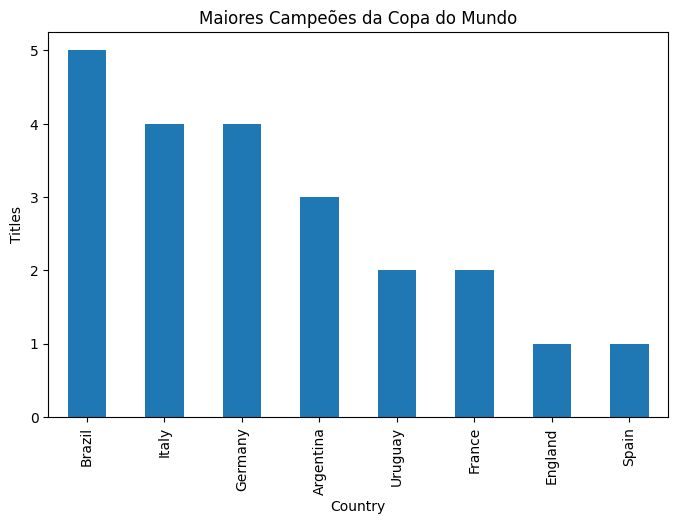

In [73]:
winners = world_cup['Winner'].value_counts()

plt.figure(figsize=(8,5))
winners.plot(kind="bar")

plt.title('Maiores Campeões da Copa do Mundo')
plt.xlabel('Country')
plt.ylabel('Titles')

plt.show()

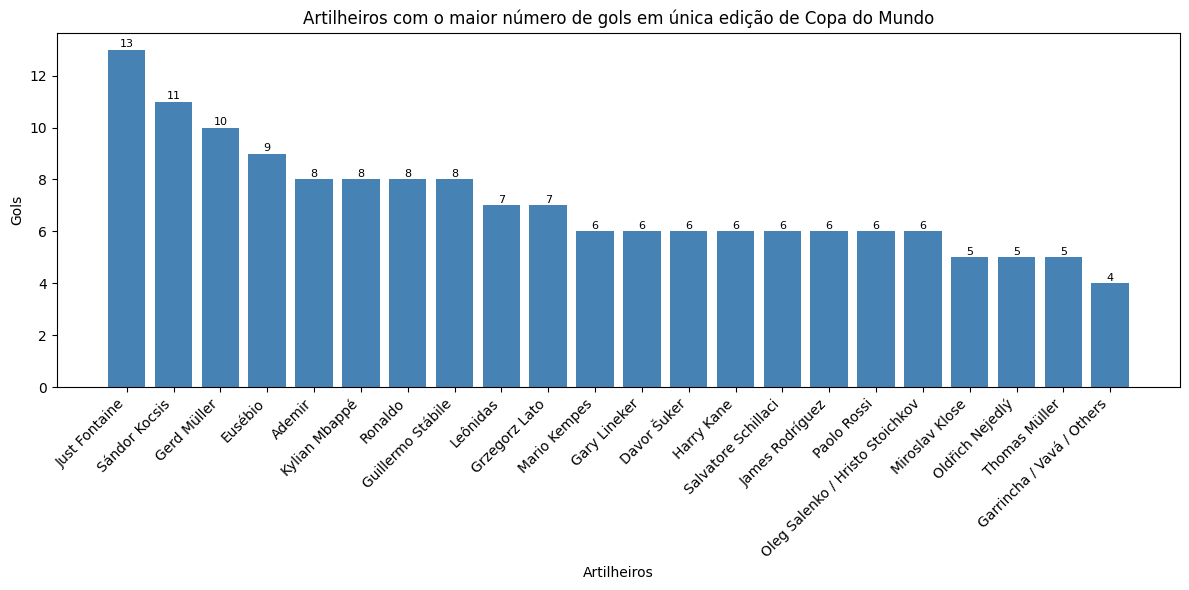

In [21]:
scorers = top_scorers.groupby('Player')['Goals'].sum().reset_index()
scorers = scorers.sort_values('Goals', ascending=False)

plt.figure(figsize=(12,6))
plt.bar(scorers['Player'], scorers['Goals'], color='steelblue')

for i, v in enumerate(scorers['Goals']):
    plt.text(i, v + 0.1, str(v), ha='center', fontsize=8)

plt.title('Artilheiros com o maior número de gols em única edição de Copa do Mundo')
plt.xlabel('Artilheiros')
plt.ylabel('Gols')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

Exportando os Csv tratados para a pasta 'base_tratada'

In [ ]:
# Pensando que o objetivo é criar uma dashboard com o tema "Copa do Mundo" foi decidido que não era necessário a utilização do dataset "competitions"

import os

caminho_arquivo = r'D:\Projeto Copa do Mundo\base_tratada'

world_cup.to_csv(os.path.join(caminho_arquivo, "world_cup.csv"), index=False)
top_scorers.to_csv(os.path.join(caminho_arquivo, "top_scorers.csv"), index=False)
rankings.to_csv(os.path.join(caminho_arquivo, "rankings.csv"), index=False)